# Swin Transformer - Sem ROI e CBAM

## Patch Embedding

* Patch Embedding é a primeira etapa da rede, responsável por transformar a imagem de entrada (pixels brutos) em uma sequência de "tokens" que o Transformer consegue processar.

In [1]:
import torch
import torch.nn as nn


class PatchEmbedding(nn.Module):

    def __init__(
        self,
        in_channels=1,
        embed_dim=96,  # cada patch será transformado em um vetor de 96 dimensões
        patch_size=4
    ):
        super().__init__()

        self.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            # filtro convolucional "olha" para blocos de 4×4 pixels
            kernel_size=patch_size,
            # pula 4 pixels a cada passo, evitando sobreposição de patches
            stride=patch_size
        )

    def forward(self, x):

        # x = (B, C_in, H, W) = (2, 1, 256, 256)

        x = self.proj(x)           # (B, embed_dim, H/4, W/4)
        x = x.permute(0, 2, 3, 1)  # permute reorganiza a dimensão para: (B, H/4, W/4, embed_dim)

        return x

In [2]:
# EXEMPLO

x = torch.randn(2, 1, 256, 256)

patch_embed = PatchEmbedding(
    in_channels=1,
    embed_dim=96,
    patch_size=4
)

y = patch_embed(x)

print(x.shape)
# cada patch agora é representado por um vetor de 96 números
print(y.shape)

torch.Size([2, 1, 256, 256])
torch.Size([2, 64, 64, 96])


## Window Partition

* Depois do Patch Embedding, temos um mapa de features tipo (B, H, W, C);
* O Window Partition simplesmente corta o mapa de features em blocos (janelas) não sobrepostos de tamanho fixo, assim a atenção pode ser calculada independentemente dentro de cada janela..

In [3]:
def window_partition(x, window_size):

    B, H, W, C = x.shape

    x = x.view(
        B,
        H // window_size,
        window_size,
        W // window_size,
        window_size,
        C
    )

    windows = x.permute(
        0, 1, 3, 2, 4, 5
    ).contiguous()

    windows = windows.view(
        -1,
        window_size,
        window_size,
        C
    )

    return windows

In [4]:
# EXEMPLO - de [2, 64, 64, 96] para [128, 8, 8, 96]

    # B = 2

    # 64 × 64
    #    ↓
    # 8 × 8 windows
    #    ↓
    # 64 windows/imagem

    # 2 × 64 = 128 windows

    # cada window:
    # 8 × 8 × 96

x = torch.randn(2, 64, 64, 96)

windows = window_partition(
    x,
    window_size=8
)

print(windows.shape)

torch.Size([128, 8, 8, 96])


## Window Reverse

* O window_reverse é a operação inversa do window_partition.

In [5]:
def window_reverse(
    windows,
    window_size,
    H,
    W
):

    B = int(
        windows.shape[0]
        / (H * W / window_size / window_size)
    )

    x = windows.view(
        B,
        H // window_size,
        W // window_size,
        window_size,
        window_size,
        -1
    )

    x = x.permute(
        0, 1, 3, 2, 4, 5
    ).contiguous()

    x = x.view(
        B,
        H,
        W,
        -1
    )

    return x

In [6]:
# EXEMPLO

x = torch.randn(2, 64, 64, 96)

windows = window_partition(x, 8)

x_reconstructed = window_reverse(
    windows,
    8,
    64,
    64
)

print(x.shape)
print(x_reconstructed.shape)

torch.Size([2, 64, 64, 96])
torch.Size([2, 64, 64, 96])


## Window Attention (W-MSA)

* A Window Attention é o módulo que aplica self-attention (multi-head) dentro de cada janela, tratando os patches daquela janela como uma sequência de tokens.

*Sendo que:*

* Cada janela de window_size × window_size patches vira uma sequência de window_size²  tokens.
* Calcula-se self-attention normal (Q, K, V) dentro dessa sequência.
* Adiciona-se um relative position bias (viés de posição relativa), como uma particularidade importante do Swin.

In [7]:
# [B_ × N, C]

# B_ = número de janelas
# N  = 8 × 8 = 64 tokens por janela
# C  = 96 features

# [128, 64, 96]

class WindowAttention(nn.Module):

    def __init__(
        self,
        dim,
        window_size,
        num_heads
    ):
        super().__init__()

        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads

        head_dim = dim // num_heads

        self.scale = head_dim ** -0.5

        # Q, K e V
        self.qkv = nn.Linear(
            dim,
            dim * 3,
            bias=True
        )

        # Projeção depois da atenção
        self.proj = nn.Linear(
            dim,
            dim
        )

    def forward(self, x):

        # x:
        # [num_windows * B, N, C]

        B_, N, C = x.shape

        qkv = self.qkv(x)

        qkv = qkv.reshape(
            B_,
            N,
            3,
            self.num_heads,
            C // self.num_heads
        )

        qkv = qkv.permute(
            2, 0, 3, 1, 4
        )

        q, k, v = qkv.unbind(0)

        # Escalação
        q = q * self.scale

        # Attention Score
        attn = q @ k.transpose(-2, -1)

        # Softmax
        attn = attn.softmax(dim=-1)

        # Aplicação sobre V - multiplicação matricial
        x = attn @ v

        # Voltar para [B_, N, C]
        x = x.transpose(1, 2)

        x = x.reshape(
            B_,
            N,
            C
        )

        # Projeção final
        x = self.proj(x)

        return x

In [8]:
# EXEMPLO

x = torch.randn(
    128,
    64,
    96
)

attention = WindowAttention(
    dim=96,
    window_size=8,
    num_heads=4
)

y = attention(x)

print(y.shape)

torch.Size([128, 64, 96])


*OBS.: A atenção não altera a quantidade de tokens nem a dimensão dos embeddings.*

## Relative Position Bias

O Swin em vez de dizer a posição exata de cada pedaço da imagem, ele avisa o quão longe um pedaço está do outro.

A lógica é, quanto mais perto ou mais longe o pedaço B estiver do pedaço A, mais (ou menos) atenção o modelo vai dar para essa relação.

### Código com o BIAS mapeado:

In [9]:
class WindowAttention(nn.Module):

    def __init__(
        self,
        dim,
        window_size,
        num_heads
    ):
        super().__init__()

        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads

        head_dim = dim // num_heads

        self.scale = head_dim ** -0.5

        # ------------------------------------------------
        # Relative Position Bias Table
        # ------------------------------------------------

        self.relative_position_bias_table = nn.Parameter(
            torch.zeros(
                (2 * window_size - 1) *
                (2 * window_size - 1),
                num_heads
            )
        )

        # ------------------------------------------------
        # Relative Position Index
        # ------------------------------------------------

        coords_h = torch.arange(window_size)
        coords_w = torch.arange(window_size)

        coords = torch.stack(
            torch.meshgrid(
                coords_h,
                coords_w,
                indexing="ij"
            )
        )

        # [2, Wh, Ww]
        coords_flatten = torch.flatten(
            coords,
            1
        )

        # [2, Wh*Ww]
        relative_coords = (
            coords_flatten[:, :, None]
            -
            coords_flatten[:, None, :]
        )

        # [2, Wh*Ww, Wh*Ww]
        relative_coords = relative_coords.permute(
            1,
            2,
            0
        ).contiguous()

        # deslocamento para valores positivos
        relative_coords[:, :, 0] += (
            window_size - 1
        )

        relative_coords[:, :, 1] += (
            window_size - 1
        )

        relative_coords[:, :, 0] *= (
            2 * window_size - 1
        )

        relative_position_index = (
            relative_coords.sum(-1)
        )

        self.register_buffer(
            "relative_position_index",
            relative_position_index
        )

        # ------------------------------------------------
        # QKV
        # ------------------------------------------------

        self.qkv = nn.Linear(
            dim,
            dim * 3
        )

        self.proj = nn.Linear(
            dim,
            dim
        )

        nn.init.trunc_normal_(
            self.relative_position_bias_table,
            std=0.02
        )

    def forward(self, x):

        B_, N, C = x.shape

        qkv = self.qkv(x)

        qkv = qkv.reshape(
            B_,
            N,
            3,
            self.num_heads,
            C // self.num_heads
        )

        qkv = qkv.permute(
            2,
            0,
            3,
            1,
            4
        )

        q, k, v = qkv.unbind(0)

        q = q * self.scale

        # ------------------------------------------------
        # Attention
        # ------------------------------------------------

        attn = q @ k.transpose(-2, -1)

        # ------------------------------------------------
        # Relative Position Bias
        # ------------------------------------------------

        relative_position_bias = (
            self.relative_position_bias_table[
                self.relative_position_index.view(-1)
            ]
        )

        relative_position_bias = (
            relative_position_bias.view(
                self.window_size *
                self.window_size,

                self.window_size *
                self.window_size,

                -1
            )
        )

        relative_position_bias = (
            relative_position_bias.permute(
                2,
                0,
                1
            ).contiguous()
        )

        attn = attn + relative_position_bias.unsqueeze(0)

        # ------------------------------------------------
        # Softmax
        # ------------------------------------------------

        attn = attn.softmax(dim=-1)

        # ------------------------------------------------
        # Attention × V
        # ------------------------------------------------

        x = attn @ v

        x = x.transpose(
            1,
            2
        ).reshape(
            B_,
            N,
            C
        )

        x = self.proj(x)

        return x

## Multi-Layer Perceptron (MPL)

O MLP é o "cérebro individual" de cada pedaço da imagem.

Enquanto a atenção faz os pedaços da imagem conversarem entre si, o MLP processa as informações de cada pedaço isoladamente para extrair características mais complexas.

O caminho que o dado faz é:

1. LayerNorm: Ajusta os valores para ficarem na mesma escala.
2. Linear (4×): Aumenta o tamanho da informação em 4 vezes para ter mais espaço de processamento.
3. GELU: Aplica a ativação (a matemática que dá o "poder de aprendizado" não-linear).
4. Linear (contrai): Encolhe a informação de volta ao tamanho original.
5. +Residual: Soma o resultado com o dado que entrou no início (para facilitar o aprendizado).

In [10]:
class MLP(nn.Module):

    def __init__(
        self,
        dim,
        hidden_dim,
        dropout=0.0
    ):
        super().__init__()

        self.fc1 = nn.Linear(
            dim,
            hidden_dim
        )

        self.act = nn.GELU()

        self.fc2 = nn.Linear(
            hidden_dim,
            dim
        )

        self.drop = nn.Dropout(
            dropout
        )

    def forward(self, x):

        x = self.fc1(x)

        x = self.act(x)

        x = self.drop(x)

        x = self.fc2(x)

        x = self.drop(x)

        return x

## Swin Transformer Block

O Swin Transformer Block é a estrutura principal que junta todas essas peças em uma etapa completa. Ele funciona como um bloco Transformer tradicional, com conexões residuais, normalização de dados e uma camada MLP mas adaptado para a imagem:

* Em vez de olhar a imagem toda de uma vez: ele processa apenas pequenas janelas.
* Como ele junta tudo: a cada bloco, ele alterna entre usar janelas normais (Regular Window) e janelas levemente movidas (Shifted Window).

Essa troca garante que o modelo não analise só os pedaços isolados, mas também aprenda como as bordas dessas janelas se conectam entre si.

In [11]:
class SwinTransformerBlock(nn.Module):

    def __init__(
        self,
        dim,
        num_heads,
        window_size=8,
        mlp_ratio=4.0
    ):
        super().__init__()

        self.dim = dim
        self.window_size = window_size

        # ---------------------------------------
        # Normalização
        # ---------------------------------------

        self.norm1 = nn.LayerNorm(dim)

        # ---------------------------------------
        # Window Attention
        # ---------------------------------------

        self.attn = WindowAttention(
            dim=dim,
            window_size=window_size,
            num_heads=num_heads
        )

        # ---------------------------------------
        # MLP
        # ---------------------------------------

        hidden_dim = int(
            dim * mlp_ratio
        )

        self.norm2 = nn.LayerNorm(dim)

        self.mlp = MLP(
            dim=dim,
            hidden_dim=hidden_dim
        )

    def forward(self, x):

        # x:
        # [B, H, W, C]

        B, H, W, C = x.shape

        shortcut = x

        # ---------------------------------------
        # LayerNorm
        # ---------------------------------------

        x = self.norm1(x)

        # ---------------------------------------
        # Window Partition
        # ---------------------------------------

        windows = window_partition(
            x,
            self.window_size
        )

        # [B*nW, Wh, Ww, C]
        # ↓
        # [B*nW, Wh*Ww, C]

        windows = windows.view(
            -1,
            self.window_size *
            self.window_size,
            C
        )

        # ---------------------------------------
        # Attention
        # ---------------------------------------

        attn_windows = self.attn(
            windows
        )

        # ---------------------------------------
        # Voltar para janelas 2D
        # ---------------------------------------

        attn_windows = attn_windows.view(
            -1,
            self.window_size,
            self.window_size,
            C
        )

        # ---------------------------------------
        # Window Reverse
        # ---------------------------------------

        x = window_reverse(
            attn_windows,
            self.window_size,
            H,
            W
        )

        # ---------------------------------------
        # Residual
        # ---------------------------------------

        x = shortcut + x

        # ---------------------------------------
        # MLP
        # ---------------------------------------

        x = x + self.mlp(
            self.norm2(x)
        )

        return x

In [12]:
# EXEMPLO - TESTANDO O SWIN TRANSFORMER

x = torch.randn(
    2,
    64,
    64,
    96
)

block = SwinTransformerBlock(
    dim=96,
    num_heads=4,
    window_size=8
)

y = block(x)

print("Entrada :", x.shape)
print("Saída   :", y.shape)

Entrada : torch.Size([2, 64, 64, 96])
Saída   : torch.Size([2, 64, 64, 96])


*OBS.: O Swin Block não reduz a resolução.*

## Shifted Window Attention (SW-MSA)

* O W-MSA (que já implementamos) tem um problema: cada janela só enxerga a si mesma, então informação de uma janela nunca conversa com a janela vizinha.
* O SW-MSA resolve isso deslocando (shift) a grade de janelas em `window_size // 2` pixels, antes de repetir o mesmo window_partition.
* Isso cria novas janelas que "cruzam" as bordas das janelas originais, permitindo que informação flua entre regiões vizinhas.
* Só que esse deslocamento cria janelas com pedaços que, na imagem original, vieram de regiões opostas (ex.: borda direita colada com a borda esquerda). Não faz sentido esses pedaços prestarem atenção uns nos outros.
* Por isso, antes de fazer o softmax, aplicamos uma **máscara de atenção**: pedaços que pertencem a regiões diferentes recebem um bias de `-100` (praticamente zero depois do softmax), impedindo que "conversem" entre si.

In [13]:
def create_mask(H, W, window_size, shift_size):

    # img_mask: identifica, para cada pixel do mapa de features,
    # a qual "região" ele pertence depois do shift
    img_mask = torch.zeros((1, H, W, 1))

    h_slices = (
        slice(0, -window_size),
        slice(-window_size, -shift_size),
        slice(-shift_size, None)
    )

    w_slices = (
        slice(0, -window_size),
        slice(-window_size, -shift_size),
        slice(-shift_size, None)
    )

    cnt = 0

    for h in h_slices:
        for w in w_slices:
            img_mask[:, h, w, :] = cnt
            cnt += 1

    # corta a máscara em janelas, do mesmo jeito que window_partition faz com x
    mask_windows = window_partition(
        img_mask,
        window_size
    )

    mask_windows = mask_windows.view(
        -1,
        window_size * window_size
    )

    # [nW, N, N] -> diferença de "região" entre cada par de tokens da janela
    attn_mask = (
        mask_windows.unsqueeze(1)
        -
        mask_windows.unsqueeze(2)
    )

    # onde a diferença é != 0 (regiões diferentes) -> -100 (bloqueia a atenção)
    # onde a diferença é == 0 (mesma região) -> 0 (atenção normal)
    attn_mask = attn_mask.masked_fill(
        attn_mask != 0, float(-100.0)
    ).masked_fill(
        attn_mask == 0, float(0.0)
    )

    return attn_mask


## Atualizando o WindowAttention para receber a máscara

* A única mudança em relação à versão com Relative Position Bias é: o `forward` agora aceita um parâmetro opcional `mask`.
* Quando `mask` é passado (nos blocos com shift), ele é somado ao `attn` antes do softmax, exatamente como o relative position bias.

In [14]:
class WindowAttention(nn.Module):

    def __init__(
        self,
        dim,
        window_size,
        num_heads
    ):
        super().__init__()

        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads

        head_dim = dim // num_heads

        self.scale = head_dim ** -0.5

        # ------------------------------------------------
        # Relative Position Bias Table
        # ------------------------------------------------

        self.relative_position_bias_table = nn.Parameter(
            torch.zeros(
                (2 * window_size - 1) *
                (2 * window_size - 1),
                num_heads
            )
        )

        # ------------------------------------------------
        # Relative Position Index
        # ------------------------------------------------

        coords_h = torch.arange(window_size)
        coords_w = torch.arange(window_size)

        coords = torch.stack(
            torch.meshgrid(
                coords_h,
                coords_w,
                indexing="ij"
            )
        )

        coords_flatten = torch.flatten(
            coords,
            1
        )

        relative_coords = (
            coords_flatten[:, :, None]
            -
            coords_flatten[:, None, :]
        )

        relative_coords = relative_coords.permute(
            1,
            2,
            0
        ).contiguous()

        relative_coords[:, :, 0] += (
            window_size - 1
        )

        relative_coords[:, :, 1] += (
            window_size - 1
        )

        relative_coords[:, :, 0] *= (
            2 * window_size - 1
        )

        relative_position_index = (
            relative_coords.sum(-1)
        )

        self.register_buffer(
            "relative_position_index",
            relative_position_index
        )

        # ------------------------------------------------
        # QKV
        # ------------------------------------------------

        self.qkv = nn.Linear(
            dim,
            dim * 3
        )

        self.proj = nn.Linear(
            dim,
            dim
        )

        nn.init.trunc_normal_(
            self.relative_position_bias_table,
            std=0.02
        )

    def forward(self, x, mask=None):

        # x:    [num_windows * B, N, C]
        # mask: [num_windows, N, N] ou None (janelas sem shift)

        B_, N, C = x.shape

        qkv = self.qkv(x)

        qkv = qkv.reshape(
            B_,
            N,
            3,
            self.num_heads,
            C // self.num_heads
        )

        qkv = qkv.permute(
            2,
            0,
            3,
            1,
            4
        )

        q, k, v = qkv.unbind(0)

        q = q * self.scale

        # ------------------------------------------------
        # Attention
        # ------------------------------------------------

        attn = q @ k.transpose(-2, -1)

        # ------------------------------------------------
        # Relative Position Bias
        # ------------------------------------------------

        relative_position_bias = (
            self.relative_position_bias_table[
                self.relative_position_index.view(-1)
            ]
        )

        relative_position_bias = (
            relative_position_bias.view(
                self.window_size *
                self.window_size,

                self.window_size *
                self.window_size,

                -1
            )
        )

        relative_position_bias = (
            relative_position_bias.permute(
                2,
                0,
                1
            ).contiguous()
        )

        attn = attn + relative_position_bias.unsqueeze(0)

        # ------------------------------------------------
        # Máscara do SW-MSA (só existe quando shift_size > 0)
        # ------------------------------------------------

        if mask is not None:

            nW = mask.shape[0]

            attn = attn.view(
                B_ // nW,
                nW,
                self.num_heads,
                N,
                N
            ) + mask.unsqueeze(1).unsqueeze(0)

            attn = attn.view(
                -1,
                self.num_heads,
                N,
                N
            )

        # ------------------------------------------------
        # Softmax
        # ------------------------------------------------

        attn = attn.softmax(dim=-1)

        # ------------------------------------------------
        # Attention × V
        # ------------------------------------------------

        x = attn @ v

        x = x.transpose(
            1,
            2
        ).reshape(
            B_,
            N,
            C
        )

        x = self.proj(x)

        return x


## Atualizando o Swin Transformer Block com Shifted Window

* Agora o bloco recebe um parâmetro `shift_size`.
* Quando `shift_size == 0` → funciona exatamente como antes (W-MSA).
* Quando `shift_size > 0` → antes do window_partition, a imagem é deslocada com `torch.roll`; depois da atenção, o deslocamento é desfeito com o roll inverso.
* A máscara criada por `create_mask` só é usada quando há shift.

In [15]:
class SwinTransformerBlock(nn.Module):

    def __init__(
        self,
        dim,
        num_heads,
        window_size=8,
        shift_size=0,
        mlp_ratio=4.0
    ):
        super().__init__()

        self.dim = dim
        self.window_size = window_size
        self.shift_size = shift_size

        # ---------------------------------------
        # Normalização
        # ---------------------------------------

        self.norm1 = nn.LayerNorm(dim)

        # ---------------------------------------
        # Window Attention
        # ---------------------------------------

        self.attn = WindowAttention(
            dim=dim,
            window_size=window_size,
            num_heads=num_heads
        )

        # ---------------------------------------
        # MLP
        # ---------------------------------------

        hidden_dim = int(
            dim * mlp_ratio
        )

        self.norm2 = nn.LayerNorm(dim)

        self.mlp = MLP(
            dim=dim,
            hidden_dim=hidden_dim
        )

    def forward(self, x):

        # x:
        # [B, H, W, C]

        B, H, W, C = x.shape

        shortcut = x

        # ---------------------------------------
        # LayerNorm
        # ---------------------------------------

        x = self.norm1(x)

        # ---------------------------------------
        # Cyclic Shift (só quando shift_size > 0)
        # ---------------------------------------

        if self.shift_size > 0:

            shifted_x = torch.roll(
                x,
                shifts=(-self.shift_size, -self.shift_size),
                dims=(1, 2)
            )

            attn_mask = create_mask(
                H,
                W,
                self.window_size,
                self.shift_size
            ).to(x.device)

        else:

            shifted_x = x
            attn_mask = None

        # ---------------------------------------
        # Window Partition
        # ---------------------------------------

        windows = window_partition(
            shifted_x,
            self.window_size
        )

        windows = windows.view(
            -1,
            self.window_size *
            self.window_size,
            C
        )

        # ---------------------------------------
        # Attention (com máscara se houver shift)
        # ---------------------------------------

        attn_windows = self.attn(
            windows,
            mask=attn_mask
        )

        # ---------------------------------------
        # Voltar para janelas 2D
        # ---------------------------------------

        attn_windows = attn_windows.view(
            -1,
            self.window_size,
            self.window_size,
            C
        )

        # ---------------------------------------
        # Window Reverse
        # ---------------------------------------

        shifted_x = window_reverse(
            attn_windows,
            self.window_size,
            H,
            W
        )

        # ---------------------------------------
        # Desfazer o Cyclic Shift
        # ---------------------------------------

        if self.shift_size > 0:

            x = torch.roll(
                shifted_x,
                shifts=(self.shift_size, self.shift_size),
                dims=(1, 2)
            )

        else:

            x = shifted_x

        # ---------------------------------------
        # Residual
        # ---------------------------------------

        x = shortcut + x

        # ---------------------------------------
        # MLP
        # ---------------------------------------

        x = x + self.mlp(
            self.norm2(x)
        )

        return x


In [16]:
# EXEMPLO - bloco com W-MSA (shift_size=0) e bloco com SW-MSA (shift_size=4)

x = torch.randn(2, 64, 64, 96)

block_wmsa = SwinTransformerBlock(
    dim=96,
    num_heads=4,
    window_size=8,
    shift_size=0
)

block_swmsa = SwinTransformerBlock(
    dim=96,
    num_heads=4,
    window_size=8,
    shift_size=4  # window_size // 2
)

y = block_wmsa(x)
y = block_swmsa(y)

print("Entrada :", x.shape)
print("Saída   :", y.shape)


Entrada : torch.Size([2, 64, 64, 96])
Saída   : torch.Size([2, 64, 64, 96])


## Patch Merging

* O Patch Merging é o responsável por reduzir a resolução espacial e aumentar o número de canais, algo parecido com o que o pooling faz nas CNNs.
* Ele pega 4 patches vizinhos (2×2), concatena os seus canais e depois usa uma camada Linear para projetar de `4C` para `2C`.
* Resultado: resolução espacial cai pela metade (H/2, W/2) e o número de canais dobra (2C). É assim que o Swin cria a estrutura hierárquica, parecida com uma CNN (feature maps cada vez menores e mais profundos).

In [17]:
class PatchMerging(nn.Module):

    def __init__(self, dim):
        super().__init__()

        self.dim = dim

        # 4 patches vizinhos concatenados (4C) -> projeção para 2C
        self.reduction = nn.Linear(
            4 * dim,
            2 * dim,
            bias=False
        )

        self.norm = nn.LayerNorm(4 * dim)

    def forward(self, x):

        # x:
        # [B, H, W, C]

        B, H, W, C = x.shape

        # pega os 4 "vizinhos" de cada bloco 2x2
        x0 = x[:, 0::2, 0::2, :]  # top-left
        x1 = x[:, 1::2, 0::2, :]  # bottom-left
        x2 = x[:, 0::2, 1::2, :]  # top-right
        x3 = x[:, 1::2, 1::2, :]  # bottom-right

        # concatena no canal: [B, H/2, W/2, 4C]
        x = torch.cat(
            [x0, x1, x2, x3],
            dim=-1
        )

        x = self.norm(x)

        # projeção: [B, H/2, W/2, 2C]
        x = self.reduction(x)

        return x


In [18]:
# EXEMPLO - de [2, 64, 64, 96] para [2, 32, 32, 192]

x = torch.randn(2, 64, 64, 96)

patch_merging = PatchMerging(dim=96)

y = patch_merging(x)

print("Entrada :", x.shape)
print("Saída   :", y.shape)


Entrada : torch.Size([2, 64, 64, 96])
Saída   : torch.Size([2, 32, 32, 192])


## Basic Layer (Stage)

* Um "stage" do Swin é uma sequência de blocos que alternam W-MSA e SW-MSA (`shift_size=0` no bloco par, `shift_size=window_size//2` no bloco ímpar), seguida (opcionalmente) por um Patch Merging no final.
* É essa alternância W-MSA / SW-MSA que faz a informação circular entre janelas vizinhas ao longo do stage.
* O último stage do modelo não tem `downsample`, pois não há mais necessidade de reduzir a resolução.

In [19]:
class BasicLayer(nn.Module):

    def __init__(
        self,
        dim,
        depth,
        num_heads,
        window_size=8,
        mlp_ratio=4.0,
        downsample=None
    ):
        super().__init__()

        # ---------------------------------------
        # Blocos: alterna W-MSA (par) e SW-MSA (ímpar)
        # ---------------------------------------

        self.blocks = nn.ModuleList([
            SwinTransformerBlock(
                dim=dim,
                num_heads=num_heads,
                window_size=window_size,
                shift_size=0 if (i % 2 == 0) else window_size // 2,
                mlp_ratio=mlp_ratio
            )
            for i in range(depth)
        ])

        # ---------------------------------------
        # Patch Merging no final do stage (se houver)
        # ---------------------------------------

        if downsample is not None:
            self.downsample = downsample(dim)
        else:
            self.downsample = None

    def forward(self, x):

        for block in self.blocks:
            x = block(x)

        if self.downsample is not None:
            x = self.downsample(x)

        return x


In [20]:
# EXEMPLO - stage com 2 blocos (W-MSA + SW-MSA) e downsample no final

x = torch.randn(2, 64, 64, 96)

stage = BasicLayer(
    dim=96,
    depth=2,
    num_heads=4,
    window_size=8,
    downsample=PatchMerging
)

y = stage(x)

print("Entrada :", x.shape)
print("Saída   :", y.shape)


Entrada : torch.Size([2, 64, 64, 96])
Saída   : torch.Size([2, 32, 32, 192])


## Swin Transformer completo

* Agora juntamos tudo:

*Patch Embedding -> 4 stages (cada um com seus blocos W-MSA/SW-MSA e Patch Merging, exceto o último) -> LayerNorm -> Global Average Pooling -> cabeça de classificação (Linear).*

* A cada stage, o número de canais dobra e a resolução espacial cai pela metade, exatamente como em uma CNN hierárquica (ResNet-like), mas usando atenção em vez de convoluções.
* `depths` e `num_heads` seguem o padrão do Swin-T (tiny) da literatura: `depths=[2, 2, 6, 2]`, `num_heads=[3, 6, 12, 24]`.

In [21]:
class SwinTransformer(nn.Module):

    def __init__(
        self,
        img_size=256,
        patch_size=4,
        in_channels=1,
        num_classes=10,
        embed_dim=96,
        depths=[2, 2, 6, 2],
        num_heads=[3, 6, 12, 24],
        window_size=8,
        mlp_ratio=4.0,
        drop_rate=0.0
    ):
        super().__init__()

        self.num_layers = len(depths)
        self.embed_dim = embed_dim
        self.num_classes = num_classes

        # ---------------------------------------
        # Patch Embedding
        # ---------------------------------------

        self.patch_embed = PatchEmbedding(
            in_channels=in_channels,
            embed_dim=embed_dim,
            patch_size=patch_size
        )

        self.pos_drop = nn.Dropout(drop_rate)

        # ---------------------------------------
        # Stages
        # ---------------------------------------

        self.layers = nn.ModuleList()

        for i_layer in range(self.num_layers):

            layer = BasicLayer(
                dim=int(embed_dim * 2 ** i_layer),
                depth=depths[i_layer],
                num_heads=num_heads[i_layer],
                window_size=window_size,
                mlp_ratio=mlp_ratio,
                # o último stage não reduz mais a resolução
                downsample=PatchMerging if (i_layer < self.num_layers - 1) else None
            )

            self.layers.append(layer)

        # ---------------------------------------
        # Cabeça de classificação
        # ---------------------------------------

        self.num_features = int(
            embed_dim * 2 ** (self.num_layers - 1)
        )

        self.norm = nn.LayerNorm(self.num_features)

        self.avgpool = nn.AdaptiveAvgPool1d(1)

        self.head = nn.Linear(
            self.num_features,
            num_classes
        )

    def forward(self, x):

        # x:
        # (B, C_in, H, W)

        x = self.patch_embed(x)

        x = self.pos_drop(x)

        # ---------------------------------------
        # Passa pelos 4 stages
        # ---------------------------------------

        for layer in self.layers:
            x = layer(x)

        # x:
        # [B, H_final, W_final, C_final]

        B, H, W, C = x.shape

        x = x.view(B, H * W, C)

        x = self.norm(x)

        # ---------------------------------------
        # Global Average Pooling
        # ---------------------------------------

        x = x.transpose(1, 2)   # [B, C, N]
        x = self.avgpool(x)     # [B, C, 1]
        x = torch.flatten(x, 1) # [B, C]

        # ---------------------------------------
        # Classificação
        # ---------------------------------------

        x = self.head(x)

        return x


In [22]:
# EXEMPLO - Swin-T (tiny) rodando fim a fim

x = torch.randn(2, 1, 256, 256)

model = SwinTransformer(
    img_size=256,
    patch_size=4,
    in_channels=1,
    num_classes=10,
    embed_dim=96,
    depths=[2, 2, 6, 2],
    num_heads=[3, 6, 12, 24],
    window_size=8
)

y = model(x)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Entrada     :", x.shape)
print("Saída (logits):", y.shape)
print(f"Parâmetros treináveis: {n_params:,}")


Entrada     : torch.Size([2, 1, 256, 256])
Saída (logits): torch.Size([2, 10])
Parâmetros treináveis: 27,531,508


## Resumo - Baseline completo

Esse notebook tem o **Swin Transformer completo**:

1. **Patch Embedding** - transforma a imagem em tokens.
2. **Window Partition / Window Reverse** - corta o mapa de features em janelas e desfaz o corte.
3. **W-MSA** (`WindowAttention` com `shift_size=0`) - atenção dentro de cada janela, com Relative Position Bias.
4. **SW-MSA** (`WindowAttention` + `create_mask` com `shift_size=window_size//2`) - desloca as janelas e mascara pares de tokens que não devem se ver, permitindo troca de informação entre janelas vizinhas.
5. **MLP** - processamento por token.
6. **Swin Transformer Block** - junta W-MSA/SW-MSA + MLP com normalização e conexões residuais.
7. **Patch Merging** - reduz resolução, dobra os canais (estrutura hierárquica).
8. **Basic Layer (Stage)** - alterna blocos W-MSA/SW-MSA e aplica o Patch Merging no final.
9. **SwinTransformer** - Patch Embedding + 4 stages + LayerNorm + Global Average Pooling + head de classificação.

Esse é o **baseline (Swin-T-like)**. Vamos efetuar algumas variações, como exemplo abaixo, para encontrar resultados melhores:

* `embed_dim` (ex.: 96 -> 128 = Swin-S/B);
* `depths` e `num_heads` (profundidade/largura de cada stage);
* `window_size` (janelas maiores custam mais caro, mas capturam contexto maior);
* `patch_size` (tokens maiores/menores na entrada);
* adicionar `DropPath` / `stochastic depth`, `Dropout` na atenção, `qkv_bias`, etc.;
* trocar o `avgpool + Linear` por outras cabeças (segmentação, detecção);
* ou ainda, modificar o **Patch Merging** para fazer uso das Wavelets.

# Treinamento e Teste no Mini-MIAS

A partir daqui, usamos a arquitetura `SwinTransformer` construída acima e aplicamos o mesmo protocolo experimental usado no notebook da CNN simples:

- Dataset **mini-MIAS** (imagens `.pgm` + classes extraídas do `00README.pdf`), classificado em 2 classes: `sem_nodulo` (NORM) e `com_nodulo` (demais achados).
- **CLAHE** para realce de contraste.
- **Stratified 5-Fold Cross-Validation** (mesma seed 42, mesmos folds).
- Métricas: Acurácia, F1-Score, AUC, matriz de confusão por fold e global.

**Ajuste importante em relação ao notebook da CNN:** o Swin Transformer construído acima usa `patch_size=4`, `window_size=8` e 4 stages (3 reduções por Patch Merging). Isso exige que a resolução da imagem seja divisível por `4 × 8 × 2³ = 256` em cada etapa. Por isso, tanto o `train_transform` quanto o `test_transform` abaixo mantêm a imagem em **256×256** (no notebook da CNN o treino usava `RandomResizedCrop(224, ...)`, o que quebraria o Swin, trocamos por `RandomResizedCrop(256, ...)` para preservar a resolução).

## 1. Preparação dos dados (mini-MIAS)

Mesma lógica do notebook `24-cnn_simples_5-Fold_MatFold.ipynb`: lê os `.pgm`, classifica via `00README.pdf`, aplica CLAHE e organiza em `dataset_cv/` para uso com `ImageFolder` + `StratifiedKFold`.

> Ajuste o caminho `PASTA_MIAs` abaixo para a pasta onde estão as imagens do mini-MIAS (`.pgm`) e o `00README.pdf` no seu ambiente.

In [23]:
!pip install PyPDF2 -q

import os
import random
import shutil
import tarfile
import zipfile
import requests

import cv2
import numpy as np
from PIL import Image
from PyPDF2 import PdfReader
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedKFold

# === CONFIGURAR SEED (mesma semente do notebook da CNN, para comparação justa) ===
def configurar_semente(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Semente {seed} configurada com sucesso!")

configurar_semente(42)

# ================================
# CONFIG
# ================================
PASTA_MIAs = "dataset-mias"

# Resolução compatível com o Swin (patch_size=4, window_size=8, 4 stages -> múltiplo de 256)
IMG_SIZE = 256

# Mirrors do mini-MIAS (com fallback entre eles - o mirror do GitHub vem primeiro
# por ser o mais estável; os dois originais (Cambridge/PEIPA) às vezes caem fora do ar)
FONTES = [
    ("https://codeload.github.com/changocoder/databases/zip/refs/heads/master", "mias_github.zip"),
    ("https://www.repository.cam.ac.uk/bitstreams/5960ab2b-5ea2-4db1-96ac-15b3605e7485/download", "mias_cam.bin"),
    ("http://peipa.essex.ac.uk/pix/mias/all-mias.tar.gz", "mias_peipa.tar.gz"),
]

HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; ColabDownloader/1.0)"}

# ================================================================
# 0. DOWNLOAD DO DATASET (COM FALLBACK ENTRE MIRRORS) - igual ao notebook da CNN
# ================================================================
def baixar_com_progresso(url, destino, timeout=60):
    print(f"Tentando baixar de: {url}")
    with requests.get(url, headers=HEADERS, stream=True, timeout=timeout) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        baixado = 0
        with open(destino, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
                    baixado += len(chunk)
                    if total:
                        pct = 100 * baixado / total
                        print(f"\r  {baixado/1e6:.0f}MB / {total/1e6:.0f}MB ({pct:.1f}%)", end="")
    print("\nDownload concluído.")

def extrair_arquivo(caminho, destino_pasta):
    with open(caminho, "rb") as f:
        assinatura = f.read(4)
    if zipfile.is_zipfile(caminho):
        print("Formato detectado: ZIP")
        with zipfile.ZipFile(caminho) as z:
            z.extractall(destino_pasta)
    elif assinatura[:2] == b"\x1f\x8b":
        print("Formato detectado: TAR.GZ")
        with tarfile.open(caminho, "r:gz") as tar:
            tar.extractall(destino_pasta)
    else:
        raise ValueError(f"Formato de arquivo não reconhecido: {caminho}")

def pasta_ja_tem_dados(pasta):
    if not os.path.isdir(pasta):
        return False
    for _, _, arquivos in os.walk(pasta):
        if any(a.endswith(".pgm") for a in arquivos):
            return True
    return False

if not pasta_ja_tem_dados(PASTA_MIAs):
    os.makedirs(PASTA_MIAs, exist_ok=True)
    sucesso = False
    for url, nome_arquivo in FONTES:
        try:
            if not os.path.exists(nome_arquivo):
                baixar_com_progresso(url, nome_arquivo, timeout=120)
            print("Extraindo arquivos...")
            extrair_arquivo(nome_arquivo, PASTA_MIAs)
            if pasta_ja_tem_dados(PASTA_MIAs):
                sucesso = True
                print(f"Sucesso! Dados extraídos em '{PASTA_MIAs}'.")
                break
            else:
                print("Extração não gerou arquivos .pgm, tentando próximo mirror...")
        except Exception as e:
            print(f"Falhou ({url}): {e}")
            continue
    if not sucesso:
        raise RuntimeError(
            "Não foi possível baixar o dataset MIAS de nenhum mirror. "
            "Baixe manualmente e faça upload para o Colab, ou monte o Google Drive."
        )
else:
    print(f"Dataset já presente em '{PASTA_MIAs}', pulando download.")

# ================================================================
# 0.1 LOCALIZAR IMAGENS E ARQUIVO DE METADADOS (BUSCA RECURSIVA)
# ================================================================
def encontrar_pgms(pasta):
    caminhos = []
    for raiz, _, arquivos in os.walk(pasta):
        for a in arquivos:
            if a.endswith(".pgm"):
                caminhos.append(os.path.join(raiz, a))
    return caminhos

def localizar_arquivo_info(pasta):
    candidatos = []
    for raiz, _, arquivos in os.walk(pasta):
        for a in arquivos:
            a_lower = a.lower()
            if "readme" in a_lower or "info" in a_lower:
                candidatos.append(os.path.join(raiz, a))
    pdfs = [c for c in candidatos if c.lower().endswith(".pdf")]
    if pdfs:
        return pdfs[0], "pdf"
    if candidatos:
        return candidatos[0], "txt"
    raise FileNotFoundError(f"Não encontrei o arquivo de metadados (README/Info) dentro de \'{pasta}\'.")

caminhos_pgm = encontrar_pgms(PASTA_MIAs)
if any(os.path.dirname(c) != PASTA_MIAs for c in caminhos_pgm):
    for c in caminhos_pgm:
        destino = os.path.join(PASTA_MIAs, os.path.basename(c))
        if not os.path.exists(destino):
            shutil.move(c, destino)

INFO_PATH, INFO_TIPO = localizar_arquivo_info(PASTA_MIAs)
print(f"Arquivo de metadados encontrado: {INFO_PATH} (tipo: {INFO_TIPO})")

# ================================
# 1. PEGAR IMAGENS
# ================================
todas_imagens = sorted([
    f for f in os.listdir(PASTA_MIAs)
    if f.endswith(".pgm")
])

print(f"Total de imagens encontradas: {len(todas_imagens)}")

# ================================
# 2. LER METADADOS (APENAS CLASSES) — PDF ou TXT
# ================================
if INFO_TIPO == "pdf":
    reader = PdfReader(INFO_PATH)
    texto_total = ""
    for pagina in reader.pages:
        txt = pagina.extract_text()
        if txt:
            texto_total += txt + "\n"
else:
    with open(INFO_PATH, "r", errors="ignore") as f:
        texto_total = f.read()

linhas = texto_total.split("\n")

mapa_classes = {}

for linha in linhas:
    linha = linha.strip()

    if linha.startswith("mdb"):
        partes = linha.split()

        if len(partes) >= 3:
            nome = partes[0] + ".pgm"
            classe = partes[2]
            mapa_classes[nome] = classe

print(f"Metadados carregados: {len(mapa_classes)} imagens classificadas.")

# ================================
# 3. CLASSIFICAÇÃO (NORM x demais achados)
# ================================
com_nodulo = []
sem_nodulo = []

for nome in todas_imagens:
    classe = mapa_classes.get(nome, None)

    if classe is None:
        continue
    elif classe == "NORM":
        sem_nodulo.append(nome)
    else:
        com_nodulo.append(nome)

print(f"Sem nódulo: {len(sem_nodulo)} | Com nódulo: {len(com_nodulo)}")

# ================================
# 4. LIMPAR E PREPARAR PASTAS
# ================================
shutil.rmtree("dataset_cv", ignore_errors=True)

os.makedirs("dataset_cv/com_nodulo", exist_ok=True)
os.makedirs("dataset_cv/sem_nodulo", exist_ok=True)

# ===========================================
# 5. CLAHE + TRANSFORMS (256x256 em treino E teste, por causa do Swin)
# ===========================================
class ApplyCLAHE:
    def __init__(self):
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __call__(self, img):
        img_np = np.array(img)

        if img_np.ndim == 3:
            img_np = img_np[..., 0]

        img_np = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        return Image.fromarray(self.clahe.apply(img_np))

# Transform de TESTE
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    ApplyCLAHE(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# Transform de TREINO (RandomResizedCrop mantido em IMG_SIZE, não em 224, para não quebrar o Swin)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    ApplyCLAHE(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# ================================================================
# 6. PROCESSAMENTO PARA CROSS-VALIDATION (imagem completa, sem ROI)
# ================================================================
def processar_para_cv(lista_com, lista_sem):
    def salvar(lista, subpasta):
        for nome in lista:
            img = cv2.imread(os.path.join(PASTA_MIAs, nome), cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            destino = os.path.join(f"dataset_cv/{subpasta}", nome)
            cv2.imwrite(destino, img)

    salvar(lista_com, "com_nodulo")
    salvar(lista_sem, "sem_nodulo")

processar_para_cv(com_nodulo, sem_nodulo)

# Dataset final
dataset_cv = datasets.ImageFolder("dataset_cv", transform=test_transform)
print(f"Dataset pronto para CV: {len(dataset_cv)} imagens.")
print(f"Classes: {dataset_cv.class_to_idx}")

targets = dataset_cv.targets
indices = np.arange(len(targets))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.1 MB/s eta 0:00:00
Semente 42 configurada com sucesso!
Tentando baixar de: https://codeload.github.com/changocoder/databases/zip/refs/heads/master

Download concluído.
Extraindo arquivos...
Formato detectado: ZIP
Sucesso! Dados extraídos em 'dataset-mias'.
Arquivo de metadados encontrado: dataset-mias/databases-master/README (tipo: txt)
Total de imagens encontradas: 322
Metadados carregados: 322 imagens classificadas.
Sem nódulo: 207 | Com nódulo: 115
Dataset pronto para CV: 322 imagens.
Classes: {'com_nodulo': 0, 'sem_nodulo': 1}


## 2. Treino + Avaliação (5-Fold Cross-Validation) com o `SwinTransformer`

Mesmo protocolo do notebook da CNN: `StratifiedKFold` com 5 partes, treino com `train_transform` (data augmentation), teste com `test_transform` (imagem "limpa"), métricas de Acurácia, F1-Score e AUC por fold + resultado global.

> `NUM_EPOCHS` e `BATCH_SIZE` foram deixados como variáveis ajustáveis: o Swin-T é bem mais pesado que a CNN simples, então talvez você precise reduzir o batch size (se faltar memória de GPU) ou o número de épocas (se o treino ficar muito lento por fold).

Variáveis faltando: skf, indices, targets, dataset_cv, train_transform, test_transform, IMG_SIZE — tentando reconstruir a partir do disco...
Reconstrução concluída: 322 imagens, classes {'com_nodulo': 0, 'sem_nodulo': 1}
Treinando no dispositivo: cuda

--- FOLD 1/5 ---


Fold 1 - épocas:   0%|          | 0/30 [00:00<?, ?it/s]

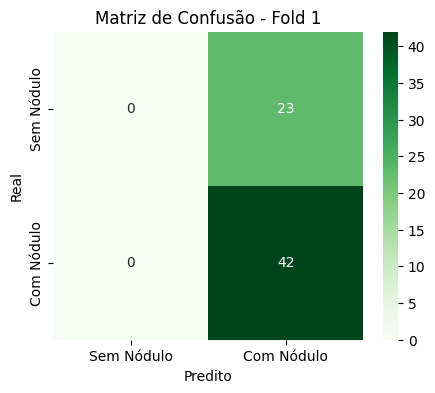

Fold 1 finalizado em 3.5 min. Acc: 64.62% | F1: 0.5073 | AUC: 0.6180

--- FOLD 2/5 ---


Fold 2 - épocas:   0%|          | 0/30 [00:00<?, ?it/s]

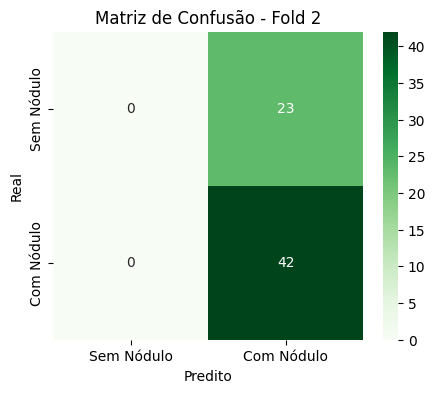

Fold 2 finalizado em 3.8 min. Acc: 64.62% | F1: 0.5073 | AUC: 0.6082

--- FOLD 3/5 ---


Fold 3 - épocas:   0%|          | 0/30 [00:00<?, ?it/s]

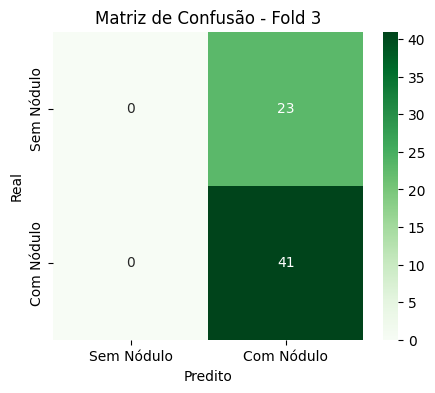

Fold 3 finalizado em 3.8 min. Acc: 64.06% | F1: 0.5003 | AUC: 0.6108

--- FOLD 4/5 ---


Fold 4 - épocas:   0%|          | 0/30 [00:00<?, ?it/s]

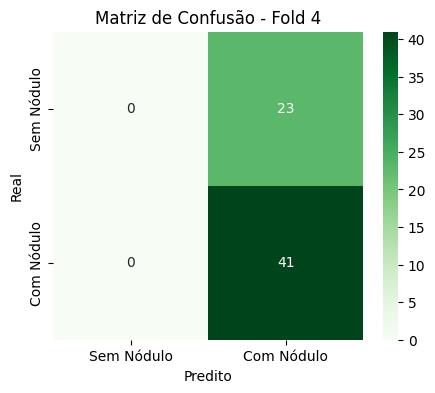

Fold 4 finalizado em 3.8 min. Acc: 64.06% | F1: 0.5003 | AUC: 0.4857

--- FOLD 5/5 ---


Fold 5 - épocas:   0%|          | 0/30 [00:00<?, ?it/s]

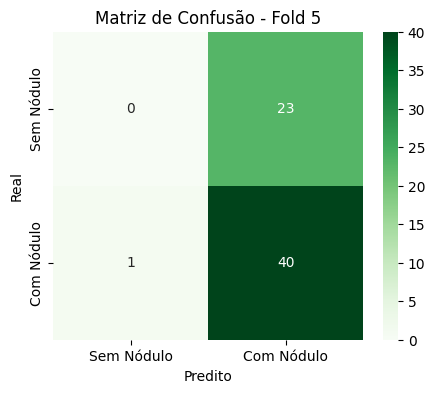

Fold 5 finalizado em 3.8 min. Acc: 62.50% | F1: 0.4928 | AUC: 0.5281

Tempo total de treino: 18.7 min

Média Final Acc: 63.97% ± 0.78
Média Final F1:  0.5016 ± 0.0054
Média Final AUC: 0.5702 ± 0.0535

==================== ANÁLISE FINAL CONSOLIDADA ====================


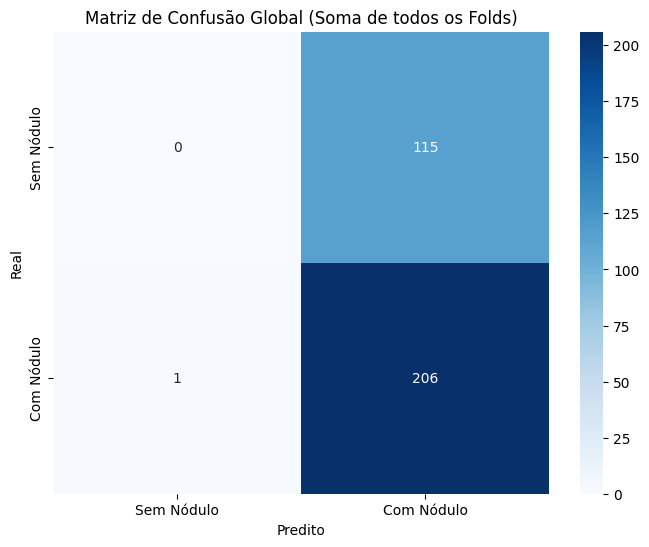

              precision    recall  f1-score   support

  Sem Nódulo       0.00      0.00      0.00       115
  Com Nódulo       0.64      1.00      0.78       207

    accuracy                           0.64       322
   macro avg       0.32      0.50      0.39       322
weighted avg       0.41      0.64      0.50       322



In [25]:
!pip install tqdm -q

import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import time
from tqdm.auto import tqdm

# ================================================================
# 0. CHECAGEM/RECONSTRUÇÃO AUTOMÁTICA DE PRÉ-REQUISITOS
# ================================================================
# Se o runtime do Colab reiniciar (ex.: ao ativar a GPU) ou esta célula
# for executada fora de ordem, as variáveis da etapa de preparação dos
# dados somem da sessão. Como as imagens já processadas continuam salvas
# em disco (pasta dataset_cv/), reconstruímos tudo aqui sem precisar
# baixar/processar o dataset de novo.
_obrigatorias = ["skf", "indices", "targets", "dataset_cv", "train_transform", "test_transform", "IMG_SIZE"]
_faltando = [v for v in _obrigatorias if v not in dir()]

if _faltando:
    print(f"Variáveis faltando: {', '.join(_faltando)} — tentando reconstruir a partir do disco...")

    if not os.path.isdir("dataset_cv") or not os.listdir("dataset_cv"):
        raise RuntimeError(
            "A pasta 'dataset_cv' não existe (ou está vazia) nesta sessão.\n"
            "Isso significa que a célula de PREPARAÇÃO DOS DADOS (download + "
            "processamento) realmente não rodou nesta sessão.\n"
            "Volte e rode, NESTA ORDEM: célula de preparação de dados -> "
            "célula do modelo SwinTransformer -> esta célula de treino.\n"
            "Dica: use 'Ambiente de execução -> Executar tudo' para garantir a ordem certa."
        )

    IMG_SIZE = 256

    class ApplyCLAHE:
        def __init__(self):
            self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

        def __call__(self, img):
            img_np = np.array(img)
            if img_np.ndim == 3:
                img_np = img_np[..., 0]
            img_np = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
            return Image.fromarray(self.clahe.apply(img_np))

    test_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        ApplyCLAHE(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])

    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        ApplyCLAHE(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])

    dataset_cv = datasets.ImageFolder("dataset_cv", transform=test_transform)
    targets = dataset_cv.targets
    indices = np.arange(len(targets))
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print(f"Reconstrução concluída: {len(dataset_cv)} imagens, classes {dataset_cv.class_to_idx}")

if "SwinTransformer" not in dir():
    raise RuntimeError(
        "A classe SwinTransformer não está definida. "
        "Rode todas as células que constroem o Swin Transformer (Patch Embedding "
        "até SwinTransformer completo) antes desta."
    )

# ================================
# CONFIG DE TREINO (ajustável)
# ================================
NUM_EPOCHS = 30       # Swin-T é mais pesado que a CNN simples; reduza se necessário
BATCH_SIZE = 16        # reduza se faltar memória de GPU
LEARNING_RATE = 3e-4

# ================================================================
# 1. DEFINIR O DISPOSITIVO (GPU) — com aviso se estiver em CPU
# ================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando no dispositivo: {device}")

if device.type == "cpu":
    print(
        "\n⚠️  ATENÇÃO: nenhuma GPU foi detectada nesta sessão.\n"
        "   Treino em CPU (5 folds x 30 épocas, Swin Transformer) pode levar HORAS.\n"
        "   Recomendado: Ambiente de execução -> Alterar tipo de ambiente de execução -> GPU (T4)\n"
        "   Depois disso o runtime reinicia e você precisa rodar tudo de novo (deps -> dados -> modelo -> treino).\n"
    )
    resposta = input("Deseja continuar mesmo assim em CPU? (s/n): ").strip().lower()
    if resposta != "s":
        raise SystemExit("Execução interrompida pelo usuário. Ative a GPU e rode tudo novamente.")

# ================================================================
# 2. LOOP DE TREINO / VALIDAÇÃO (5-FOLD)
# ================================================================
acc_folds, f1_folds, auc_folds = [], [], []

## Listas para acumular o resultado GLOBAL
todas_labels_global = []
todas_predicoes_global = []

tempo_inicio_total = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(indices, targets), 1):
    print(f"\n--- FOLD {fold}/5 ---")
    tempo_inicio_fold = time.time()

    # Criar Subsets
    train_sub = torch.utils.data.Subset(dataset_cv, train_idx)
    val_sub = torch.utils.data.Subset(dataset_cv, val_idx)

    # No treino, usamos aumento de dados (train_transform)
    train_sub.dataset.transform = train_transform
    loader_train = DataLoader(train_sub, batch_size=BATCH_SIZE, shuffle=True)

    # Na validação (teste do fold), usamos a imagem limpa (test_transform)
    val_sub.dataset.transform = test_transform
    loader_val = DataLoader(val_sub, batch_size=BATCH_SIZE, shuffle=False)

    # Inicializa o SwinTransformer (Swin-T-like) na GPU
    model = SwinTransformer(
        img_size=IMG_SIZE,
        patch_size=4,
        in_channels=1,
        num_classes=2,
        embed_dim=96,
        depths=[2, 2, 6, 2],
        num_heads=[3, 6, 12, 24],
        window_size=8,
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()

    # LOOP DE TREINO com barra de progresso
    pbar_epocas = tqdm(range(NUM_EPOCHS), desc=f"Fold {fold} - épocas")
    for epoch in pbar_epocas:
        model.train()
        epoch_loss = 0.0
        n_batches = 0

        for imagens, labels in loader_train:
            imagens, labels = imagens.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imagens)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        pbar_epocas.set_postfix(loss=f"{epoch_loss / n_batches:.4f}")

    # BLOCO DE TESTE DO FOLD
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    with torch.no_grad():
        for imagens, labels in loader_val:
            imagens, labels = imagens.to(device), labels.to(device)
            outputs = model(imagens)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_probs.extend(probs.cpu().numpy()[:, 1])

    # === MATRIZ DE CONFUSÃO DO FOLD ATUAL ===
    plt.figure(figsize=(5, 4))
    cm_fold = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm_fold, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Sem Nódulo', 'Com Nódulo'],
                yticklabels=['Sem Nódulo', 'Com Nódulo'])
    plt.title(f'Matriz de Confusão - Fold {fold}')
    plt.ylabel('Real')
    plt.xlabel('Predito')
    plt.show()

    # Acumula para o Global
    todas_labels_global.extend(y_true)
    todas_predicoes_global.extend(y_pred)

    # Cálculo das métricas
    acc_folds.append(accuracy_score(y_true, y_pred))
    f1_folds.append(f1_score(y_true, y_pred, average='weighted'))
    auc_folds.append(roc_auc_score(y_true, y_probs))

    tempo_fold = time.time() - tempo_inicio_fold
    print(f"Fold {fold} finalizado em {tempo_fold/60:.1f} min. "
          f"Acc: {acc_folds[-1]*100:.2f}% | F1: {f1_folds[-1]:.4f} | AUC: {auc_folds[-1]:.4f}")

tempo_total = time.time() - tempo_inicio_total
print(f"\nTempo total de treino: {tempo_total/60:.1f} min")

# RESULTADOS FINAIS
print("\n" + "="*40)
print(f"Média Final Acc: {np.mean(acc_folds)*100:.2f}% ± {np.std(acc_folds)*100:.2f}")
print(f"Média Final F1:  {np.mean(f1_folds):.4f} ± {np.std(f1_folds):.4f}")
print(f"Média Final AUC: {np.mean(auc_folds):.4f} ± {np.std(auc_folds):.4f}")
print("="*40)

# === APÓS O LOOP DE TODOS OS FOLDS: MATRIZ GLOBAL ===
print("\n" + "="*20 + " ANÁLISE FINAL CONSOLIDADA " + "="*20)

plt.figure(figsize=(8, 6))
cm_global = confusion_matrix(todas_labels_global, todas_predicoes_global)
sns.heatmap(cm_global, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sem Nódulo', 'Com Nódulo'],
            yticklabels=['Sem Nódulo', 'Com Nódulo'])
plt.title('Matriz de Confusão Global (Soma de todos os Folds)')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

# Relatório estatístico completo
print(classification_report(todas_labels_global, todas_predicoes_global,
                            target_names=['Sem Nódulo', 'Com Nódulo']))
